# Business Problem

# Import Libraries

In [24]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load Dataset

In [25]:
df = pd.read_csv('/Users/professorx/Projects/Capstone/project_work/data/raw/diabetic_data.csv',na_values="?")

/var/folders/xb/xc1k2vhn2tz0kg742hb726080000gn/T/ipykernel_4465/1695204803.py:1: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/Users/professorx/Projects/Capstone/project_work/data/raw/diabetic_data.csv',na_values="?")


# Dataset Overview

In [26]:
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),NaN,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),NaN,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [43]:
df.tail()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
101761,443847548,100162476,AfricanAmerican,Male,[70-80),NaN,1,3,7,3,...,No,Down,No,No,No,No,No,Ch,Yes,>30
101762,443847782,74694222,AfricanAmerican,Female,[80-90),NaN,1,4,5,5,...,No,Steady,No,No,No,No,No,No,Yes,NO
101763,443854148,41088789,Caucasian,Male,[70-80),NaN,1,1,7,1,...,No,Down,No,No,No,No,No,Ch,Yes,NO
101764,443857166,31693671,Caucasian,Female,[80-90),NaN,2,3,7,10,...,No,Up,No,No,No,No,No,Ch,Yes,NO
101765,443867222,175429310,Caucasian,Male,[70-80),NaN,1,1,7,6,...,No,No,No,No,No,No,No,No,No,NO


In [44]:
df.sample(10)

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
27080,88816788,85400073,Caucasian,Female,[60-70),[75-100),5,6,4,10,...,No,No,No,No,No,No,No,Ch,Yes,NO
101437,439118984,90092583,Caucasian,Female,[90-100),NaN,1,22,7,4,...,No,No,No,No,No,No,No,No,No,<30
52178,154749678,111882843,Caucasian,Male,[80-90),NaN,1,1,7,4,...,No,No,No,No,No,No,No,No,Yes,>30
61316,171230934,24896313,AfricanAmerican,Female,[70-80),NaN,3,1,1,4,...,No,Up,No,No,No,No,No,Ch,Yes,NO
58046,164946138,40925529,Caucasian,Female,[70-80),NaN,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
19766,70199034,79916499,Caucasian,Female,[70-80),NaN,2,1,1,12,...,No,No,No,No,No,No,No,No,Yes,NO
11020,46072026,2989062,Caucasian,Male,[60-70),NaN,2,18,1,5,...,No,No,No,No,No,No,No,Ch,Yes,NO
86765,276104862,40868154,Caucasian,Female,[80-90),NaN,1,13,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
101426,439061744,90489195,Caucasian,Female,[30-40),NaN,1,1,7,5,...,No,Up,No,No,No,No,No,Ch,Yes,>30
48097,147202800,97581213,Caucasian,Female,[80-90),NaN,2,5,7,5,...,No,Steady,No,No,No,No,No,No,Yes,NO


In [27]:
df.shape

(101766, 50)

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      99493 non-null   object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    3197 non-null    object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                61510 non-null   object
 11  medical_specialty         51817 non-null   object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

In [29]:
df.describe()

,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,1.017660e+05,1.017660e+05,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,1.652016e+08,5.433040e+07,2.024006,3.715642,5.754437,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,1.026403e+08,3.869636e+07,1.445403,5.280166,4.064081,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.252200e+04,1.350000e+02,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,8.496119e+07,2.341322e+07,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,1.523890e+08,4.550514e+07,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,2.302709e+08,8.754595e+07,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,4.438672e+08,1.895026e+08,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


# Missing Value Analysis

In [30]:
df.isnull().sum()

encounter_id                    0
patient_nbr                     0
race                         2273
gender                          0
age                             0
weight                      98569
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                  40256
medical_specialty           49949
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                         21
diag_2                        358
diag_3                       1423
number_diagnoses                0
max_glu_serum               96420
A1Cresult                   84748
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
acetohexamide 

In [50]:
null_rows = df.isnull().mean().mul(100).round(2)
print(null_rows)

encounter_id                 0.00
patient_nbr                  0.00
race                         2.23
gender                       0.00
age                          0.00
weight                      96.86
admission_type_id            0.00
discharge_disposition_id     0.00
admission_source_id          0.00
time_in_hospital             0.00
payer_code                  39.56
medical_specialty           49.08
num_lab_procedures           0.00
num_procedures               0.00
num_medications              0.00
number_outpatient            0.00
number_emergency             0.00
number_inpatient             0.00
diag_1                       0.02
diag_2                       0.35
diag_3                       1.40
number_diagnoses             0.00
max_glu_serum               94.75
A1Cresult                   83.28
metformin                    0.00
repaglinide                  0.00
nateglinide                  0.00
chlorpropamide               0.00
glimepiride                  0.00
acetohexamide 

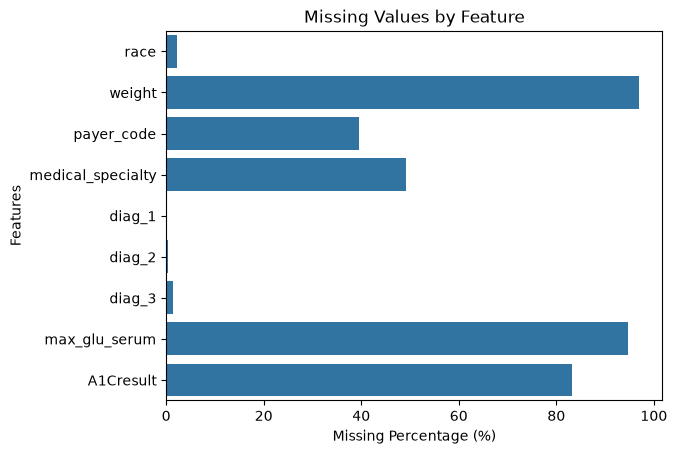

In [51]:
sns.barplot(
    x=null_rows[null_rows > 0].values,
    y=null_rows[null_rows > 0].index
)

plt.xlabel("Missing Percentage (%)")
plt.ylabel("Features")
plt.title("Missing Values by Feature")

plt.show()

- Chances to drop the columns with 80% higher null values

# Data Types

In [52]:
df.duplicated().sum()

np.int64(0)

In [53]:
df["patient_nbr"].duplicated().sum()

np.int64(30248)

In [54]:
df["patient_nbr"].nunique()

71518

In [55]:
df["encounter_id"].nunique()

101766

# Target Variable Analysis

In [56]:
df['readmitted'].value_counts()

readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

In [57]:
# Percentage
df['readmitted'].value_counts(normalize=True).round(4) * 100

readmitted
NO     53.91
>30    34.93
<30    11.16
Name: proportion, dtype: float64

Task was destroyed but it is pending!
task: <Task pending name='Task-469' coro=<_async_in_context.<locals>.run_in_context() done, defined at /Users/professorx/Projects/Capstone/project_work/.venv/lib/python3.11/site-packages/ipykernel/utils.py:57> wait_for=<Task pending name='Task-470' coro=<Kernel.shell_main() running at /Users/professorx/Projects/Capstone/project_work/.venv/lib/python3.11/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /Users/professorx/Projects/Capstone/project_work/.venv/lib/python3.11/site-packages/zmq/eventloop/zmqstream.py:563]>
/Users/professorx/Projects/Capstone/project_work/.venv/lib/python3.11/site-packages/matplotlib/cbook.py:270: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  self._cid_gen = itertools.count()
Task was destroyed but it is pending!
task: <Task pending name='Task-470' coro=<Kernel.shell_main() running at /Users/professorx/Projects/Capstone/project_work

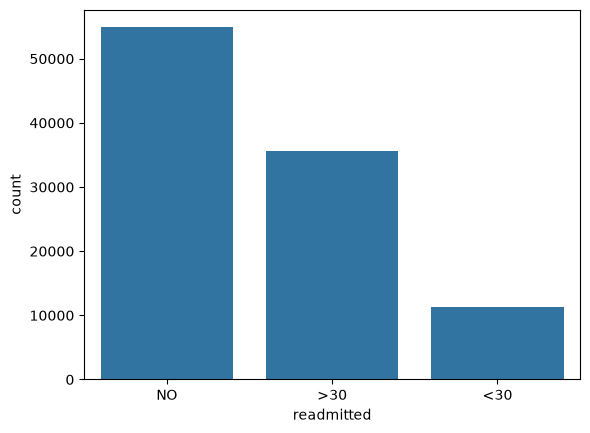

In [58]:
sns.countplot(data=df,x='readmitted')
plt.show()

# Numerical Feature Analysis

In [63]:
numerical_cols = [
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "number_diagnoses"
]

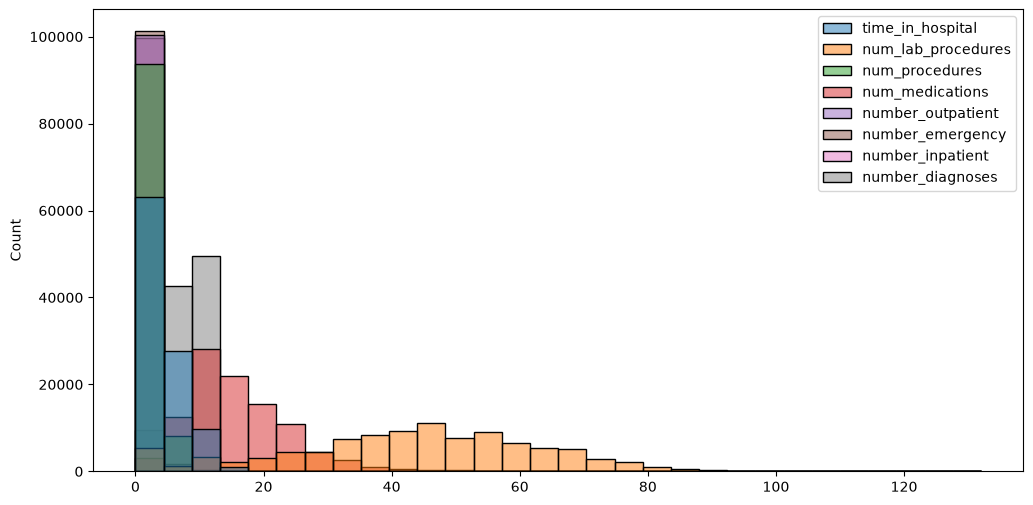

In [66]:
plt.figure(figsize=(12,6))
sns.histplot(data=df[numerical_cols],bins=30)

plt.show()


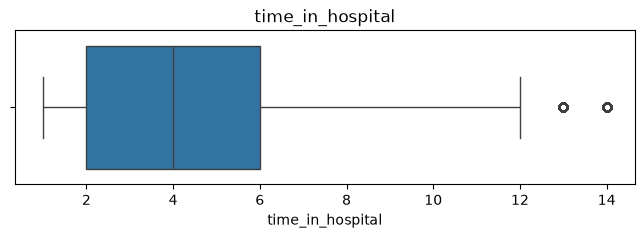

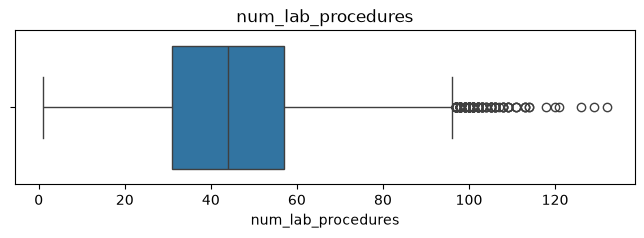

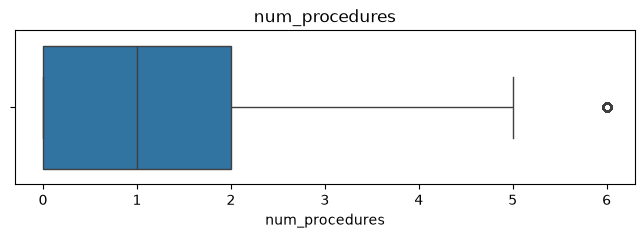

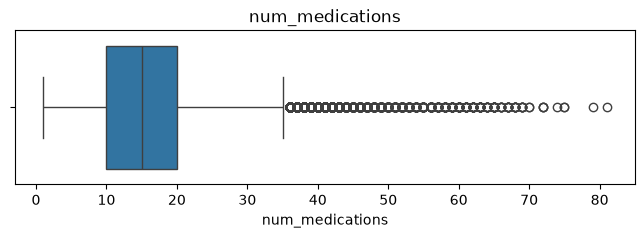

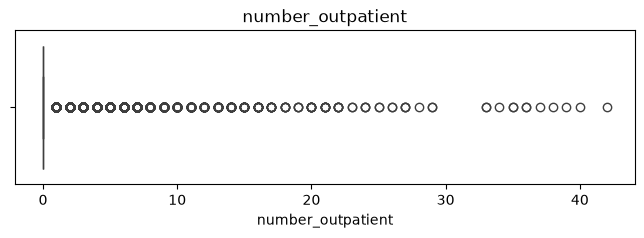

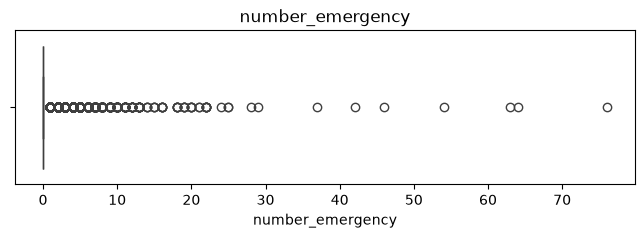

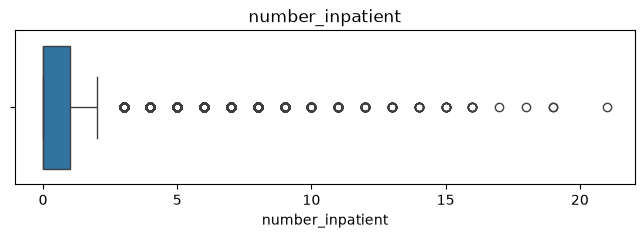

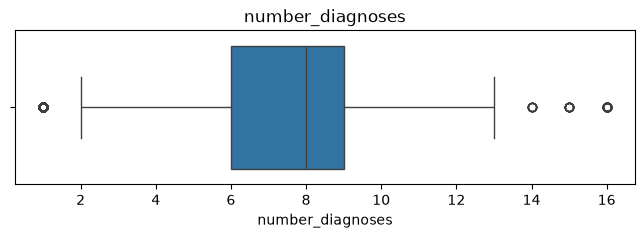

In [68]:
for col in numerical_cols:
    plt.figure(figsize=(8,2))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

# Categorical Feature Analysis

In [70]:
df.nunique().sort_values()

citoglipton                      1
examide                          1
acetohexamide                    2
glipizide-metformin              2
tolbutamide                      2
troglitazone                     2
metformin-rosiglitazone          2
glimepiride-pioglitazone         2
metformin-pioglitazone           2
change                           2
diabetesMed                      2
gender                           3
tolazamide                       3
readmitted                       3
max_glu_serum                    3
A1Cresult                        3
acarbose                         4
rosiglitazone                    4
pioglitazone                     4
miglitol                         4
glimepiride                      4
metformin                        4
nateglinide                      4
repaglinide                      4
chlorpropamide                   4
glipizide                        4
glyburide                        4
insulin                          4
glyburide-metformin 

In [71]:
df['gender'].value_counts()

gender
Female             54708
Male               47055
Unknown/Invalid        3
Name: count, dtype: int64

In [72]:
df['age'].value_counts()

age
[70-80)     26068
[60-70)     22483
[50-60)     17256
[80-90)     17197
[40-50)      9685
[30-40)      3775
[90-100)     2793
[20-30)      1657
[10-20)       691
[0-10)        161
Name: count, dtype: int64

In [73]:
df['race'].value_counts()

race
Caucasian          76099
AfricanAmerican    19210
Hispanic            2037
Other               1506
Asian                641
Name: count, dtype: int64

# Bivariate Analysis

In [74]:
# Target -> Readmission
# Readmission vs Age
pd.crosstab(df['age'],df['readmitted'])

readmitted,<30,>30,NO
age,,,
[0-10),3,26,132
[10-20),40,224,427
[20-30),236,510,911
[30-40),424,1187,2164
[40-50),1027,3278,5380
[50-60),1668,5917,9671
[60-70),2502,7897,12084
[70-80),3069,9475,13524
[80-90),2078,6223,8896


<Axes: xlabel='age', ylabel='count'>

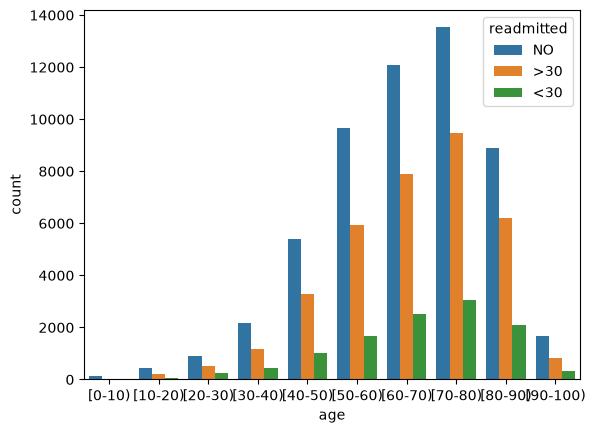

In [79]:
sns.countplot(data=df,x='age',hue='readmitted')

<Axes: xlabel='gender', ylabel='count'>

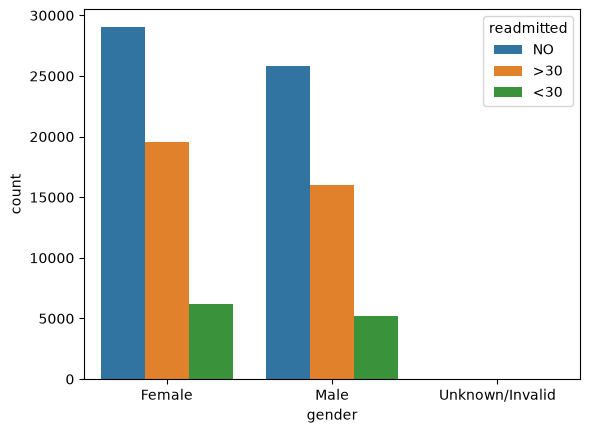

In [80]:
sns.countplot(data=df,x='gender',hue='readmitted')

<Axes: xlabel='race', ylabel='count'>

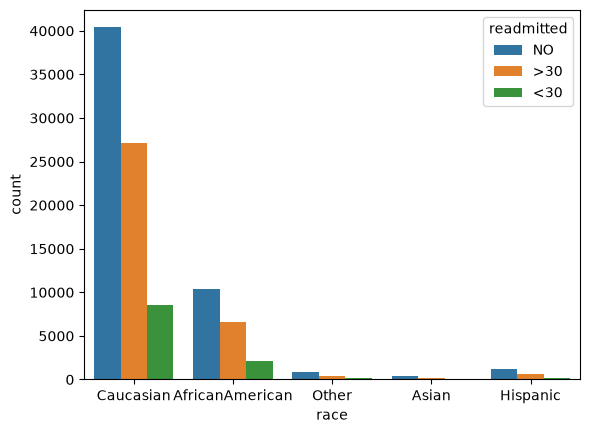

In [83]:
sns.countplot(
    data=df,
    x="race",
    hue="readmitted"
)

<Axes: xlabel='readmitted', ylabel='number_inpatient'>

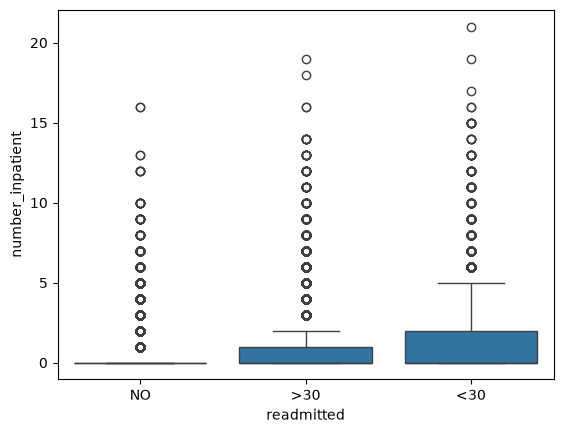

In [82]:
sns.boxplot(
    data=df,
    x="readmitted",
    y="number_inpatient"
)

# Correlation Analysis

In [85]:
corr = df[numerical_cols].corr()
corr

,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
time_in_hospital,1.000000,0.318450,0.191472,0.466135,-0.008916,-0.009681,0.073623,0.220186
num_lab_procedures,0.318450,1.000000,0.058066,0.268161,-0.007602,-0.002279,0.039231,0.152773
num_procedures,0.191472,0.058066,1.000000,0.385767,-0.024819,-0.038179,-0.066236,0.073734
num_medications,0.466135,0.268161,0.385767,1.000000,0.045197,0.013180,0.064194,0.261526
number_outpatient,-0.008916,-0.007602,-0.024819,0.045197,1.000000,0.091459,0.107338,0.094152
number_emergency,-0.009681,-0.002279,-0.038179,0.013180,0.091459,1.000000,0.266559,0.055539
number_inpatient,0.073623,0.039231,-0.066236,0.064194,0.107338,0.266559,1.000000,0.104710
number_diagnoses,0.220186,0.152773,0.073734,0.261526,0.094152,0.055539,0.104710,1.000000


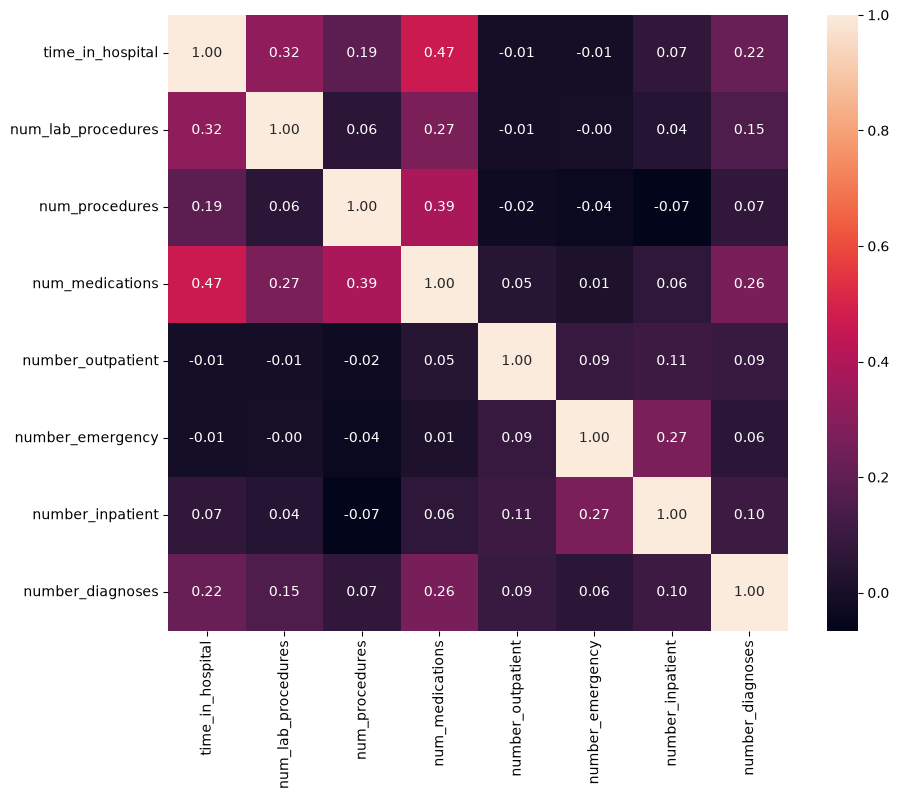

In [87]:
plt.figure(figsize=(10,8))

sns.heatmap(corr,annot=True,fmt='.2f')
plt.show()

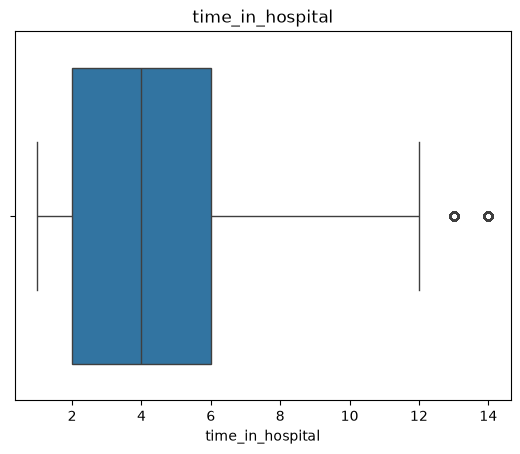

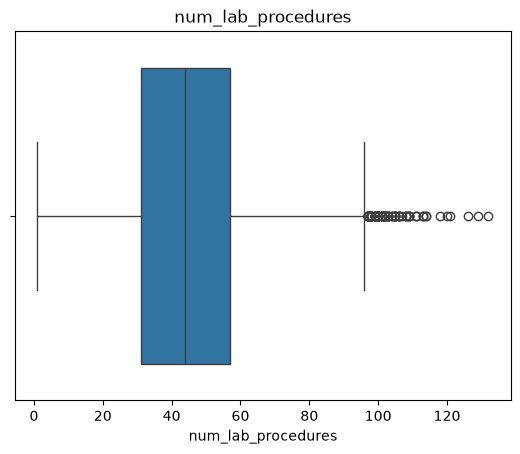

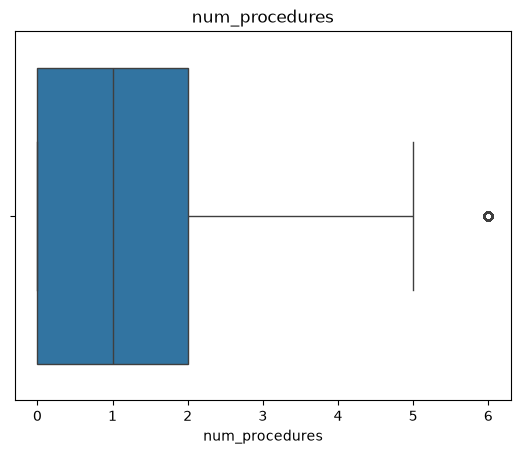

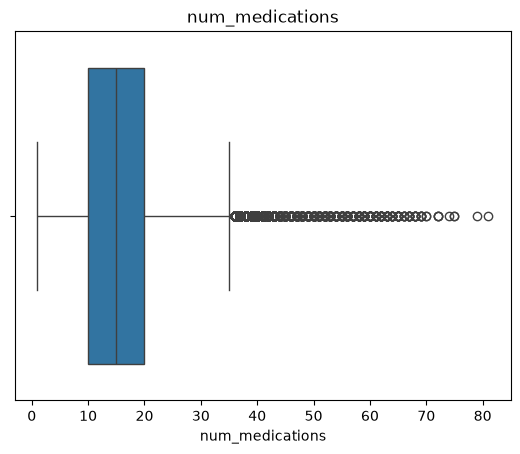

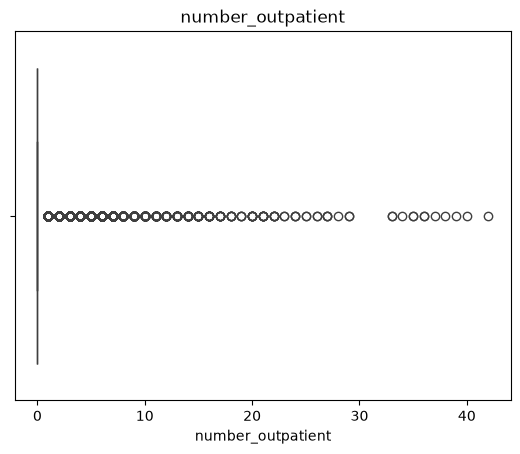

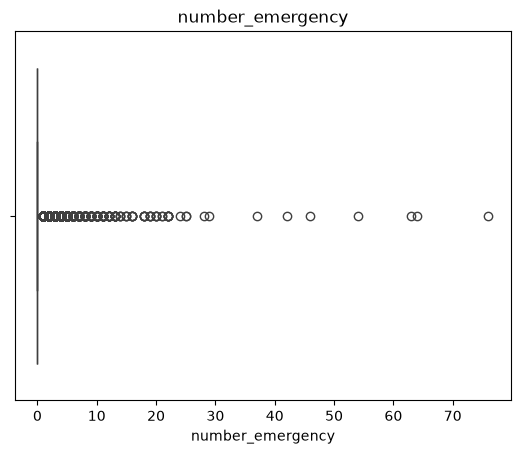

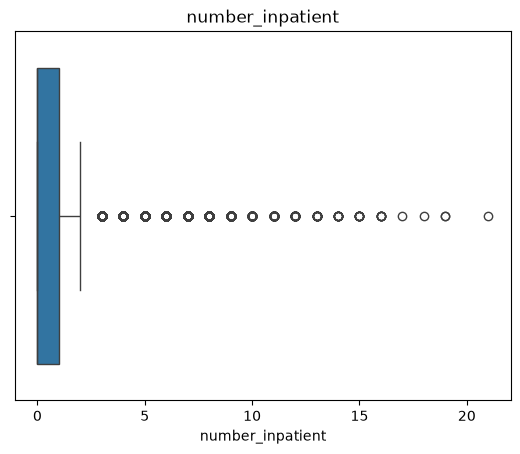

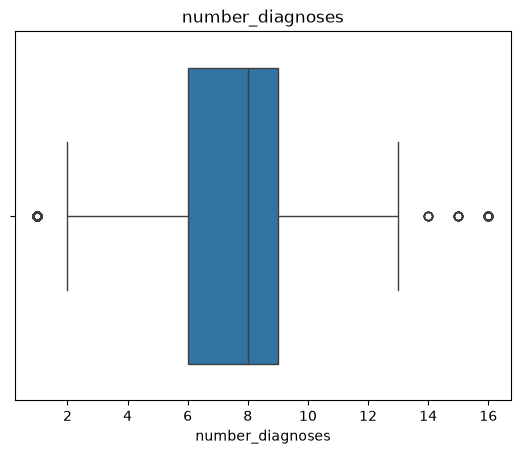

In [92]:
for col in numerical_cols:
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

# Data Quality Checks

In [91]:
df['readmitted'].value_counts(normalize=True).mul(100)

readmitted
NO     53.911916
>30    34.928169
<30    11.159916
Name: proportion, dtype: float64

In [ ]:
# Key Findings